Nota do serviço (0-10) [7]: 8
Nota da comida (0-10) [3]: 9

=> Gorjeta sugerida: 15.3%


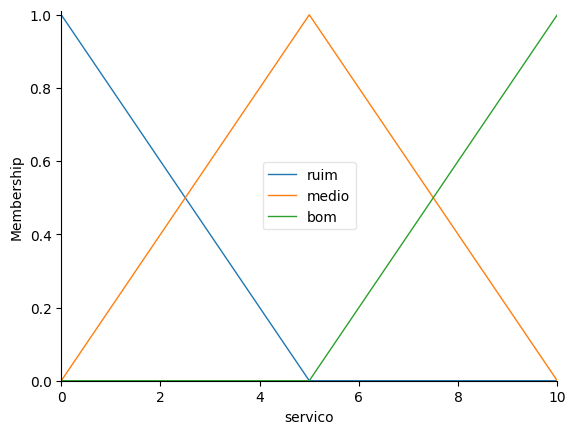

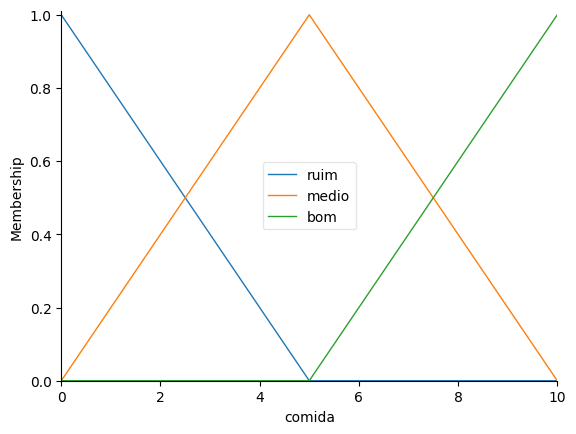

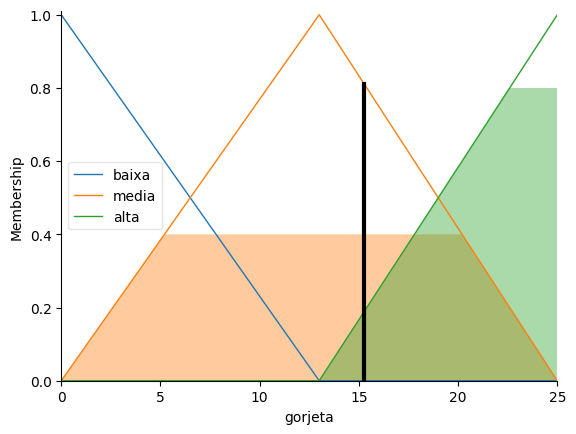

In [4]:
"""
AULA DE LÓGICA FUZZY - Código 2 (laboratório dos alunos)

Mesmo problema da gorjeta, agora com a biblioteca scikit-fuzzy.
Você vai: (1) rodar, (2) ver os gráficos, (3) fazer os experimentos no final.

Instalação:  pip install numpy matplotlib scikit-fuzzy
Execução:    python 02_laboratorio_skfuzzy.py
"""
import numpy as np
import matplotlib.pyplot as plt
import skfuzzy as fuzz
from skfuzzy import control as ctrl

# ---------- 1) Variáveis linguísticas (universos de discurso) ----------
servico = ctrl.Antecedent(np.arange(0, 10.01, 0.1), "servico")   # nota 0-10
comida = ctrl.Antecedent(np.arange(0, 10.01, 0.1), "comida")     # nota 0-10
gorjeta = ctrl.Consequent(np.arange(0, 25.01, 0.5), "gorjeta")   # % da conta

# ---------- 2) Conjuntos fuzzy (funções de pertinência) ----------
for var in (servico, comida):
    var["ruim"] = fuzz.trimf(var.universe, [0, 0, 5])
    var["medio"] = fuzz.trimf(var.universe, [0, 5, 10])
    var["bom"] = fuzz.trimf(var.universe, [5, 10, 10])

gorjeta["baixa"] = fuzz.trimf(gorjeta.universe, [0, 0, 13])
gorjeta["media"] = fuzz.trimf(gorjeta.universe, [0, 13, 25])
gorjeta["alta"] = fuzz.trimf(gorjeta.universe, [13, 25, 25])

# ---------- 3) Base de regras  (| = OU, & = E, ~ = NÃO) ----------
regras = [
    ctrl.Rule(servico["ruim"] | comida["ruim"], gorjeta["baixa"]),
    ctrl.Rule(servico["medio"], gorjeta["media"]),
    ctrl.Rule(servico["bom"] | comida["bom"], gorjeta["alta"]),
]

# ---------- 4) Simulação ----------
sistema = ctrl.ControlSystem(regras)
sim = ctrl.ControlSystemSimulation(sistema)


def pedir_nota(texto, padrao):
    """Lê uma nota de 0 a 10; se o aluno só apertar Enter, usa o padrão."""
    resposta = input(f"{texto} (0-10) [{padrao}]: ").strip()
    return float(resposta.replace(",", ".")) if resposta else padrao


sim.input["servico"] = pedir_nota("Nota do serviço", 7)
sim.input["comida"] = pedir_nota("Nota da comida", 3)
sim.compute()
print(f"\n=> Gorjeta sugerida: {sim.output['gorjeta']:.1f}%")

# ---------- 5) Gráficos ----------
servico.view()                 # funções de pertinência do serviço
comida.view()                  # funções de pertinência da comida
gorjeta.view(sim=sim)          # área agregada + linha do centroide (resultado)
plt.show()

# ======================= EXPERIMENTOS =======================
# 1) Troque a regra 2 por:  servico["medio"] & comida["medio"]
#    O que mudou no resultado para (7, 3)? Por quê?
# 2) Troque os triângulos de "servico" por trapézios (fuzz.trapmf) ou
#    gaussianas (fuzz.gaussmf, [media, desvio]). O resultado ficou mais suave?
# 3) Compare métodos de defuzzificação:
#      gorjeta = ctrl.Consequent(np.arange(0, 25.01, 0.5), "gorjeta",
#                                defuzzify_method="mom")   # "centroid", "bisector", "mom"...
# 4) Adicione um 4º conjunto "excelente" ao serviço e escreva a regra nova.
# 5) Teste (0, 0), (10, 10), (5, 5): o comportamento é o que você esperava?


Nota do serviço (0-10) [7]: 
Nota da comida (0-10) [3]: 

=> Gorjeta sugerida: 12.5%


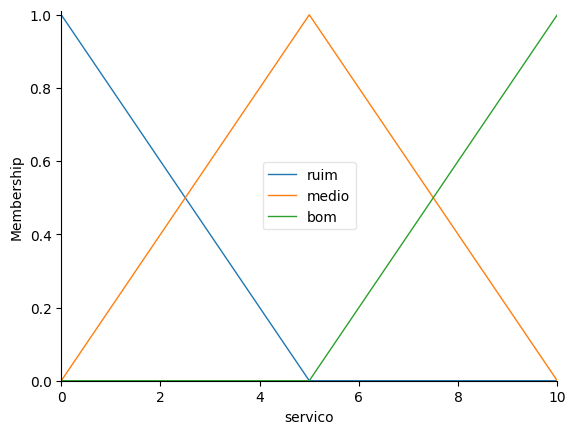

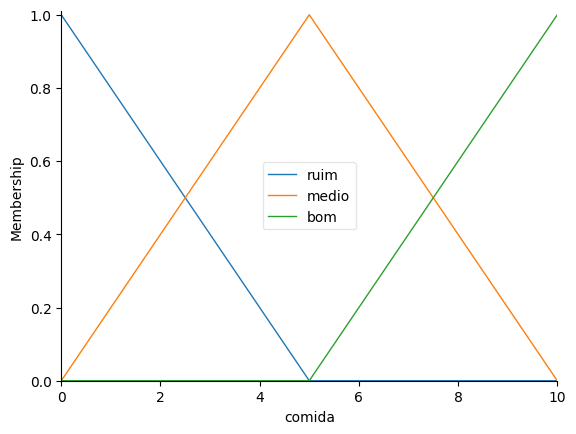

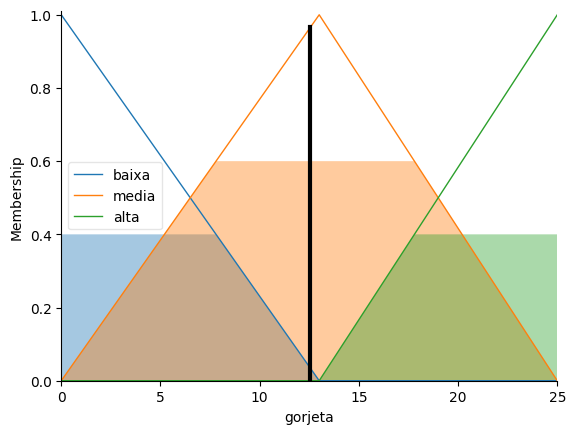

In [18]:
"""
AULA DE LÓGICA FUZZY - Código 2 (laboratório dos alunos)

Mesmo problema da gorjeta, agora com a biblioteca scikit-fuzzy.
Você vai: (1) rodar, (2) ver os gráficos, (3) fazer os experimentos no final.

Instalação:  pip install numpy matplotlib scikit-fuzzy
Execução:    python 02_laboratorio_skfuzzy.py
"""
import numpy as np
import matplotlib.pyplot as plt
import skfuzzy as fuzz
from skfuzzy import control as ctrl

# ---------- 1) Variáveis linguísticas (universos de discurso) ----------
servico = ctrl.Antecedent(np.arange(0, 10.01, 0.1), "servico")   # nota 0-10
comida = ctrl.Antecedent(np.arange(0, 10.01, 0.1), "comida")     # nota 0-10
gorjeta = ctrl.Consequent(np.arange(0, 25.01, 0.5), "gorjeta")   # % da conta

# ---------- 2) Conjuntos fuzzy (funções de pertinência) ----------
for var in (servico, comida):
    var["ruim"] = fuzz.trimf(var.universe, [0, 0, 5])
    var["medio"] = fuzz.trimf(var.universe, [0, 5, 10])
    var["bom"] = fuzz.trimf(var.universe, [5, 10, 10])

gorjeta["baixa"] = fuzz.trimf(gorjeta.universe, [0, 0, 13])
gorjeta["media"] = fuzz.trimf(gorjeta.universe, [0, 13, 25])
gorjeta["alta"] = fuzz.trimf(gorjeta.universe, [13, 25, 25])

# ---------- 3) Base de regras  (| = OU, & = E, ~ = NÃO) ----------
regras = [
    ctrl.Rule(servico["ruim"] | comida["ruim"], gorjeta["baixa"]),
    ctrl.Rule(servico["medio"] & comida["medio"], gorjeta["media"]),
    ctrl.Rule(servico["bom"] | comida["bom"], gorjeta["alta"]),
]

# ---------- 4) Simulação ----------
sistema = ctrl.ControlSystem(regras)
sim = ctrl.ControlSystemSimulation(sistema)


def pedir_nota(texto, padrao):
    """Lê uma nota de 0 a 10; se o aluno só apertar Enter, usa o padrão."""
    resposta = input(f"{texto} (0-10) [{padrao}]: ").strip()
    return float(resposta.replace(",", ".")) if resposta else padrao


sim.input["servico"] = pedir_nota("Nota do serviço", 7)
sim.input["comida"] = pedir_nota("Nota da comida", 3)
sim.compute()
print(f"\n=> Gorjeta sugerida: {sim.output['gorjeta']:.1f}%")

# ---------- 5) Gráficos ----------
servico.view()                 # funções de pertinência do serviço
comida.view()                  # funções de pertinência da comida
gorjeta.view(sim=sim)          # área agregada + linha do centroide (resultado)
plt.show()

# ======================= EXPERIMENTOS =======================
# 1) Troque a regra 2 por:  servico["medio"] & comida["medio"]
#    O que mudou no resultado para (7, 3)? Por quê?
# 2) Troque os triângulos de "servico" por trapézios (fuzz.trapmf) ou
#    gaussianas (fuzz.gaussmf, [media, desvio]). O resultado ficou mais suave?
# 3) Compare métodos de defuzzificação:
#      gorjeta = ctrl.Consequent(np.arange(0, 25.01, 0.5), "gorjeta",
#                                defuzzify_method="mom")   # "centroid", "bisector", "mom"...
# 4) Adicione um 4º conjunto "excelente" ao serviço e escreva a regra nova.
# 5) Teste (0, 0), (10, 10), (5, 5): o comportamento é o que você esperava?


Nota do serviço (0-10) [7]: 
Nota da comida (0-10) [3]: 

=> Gorjeta sugerida: 11.5%


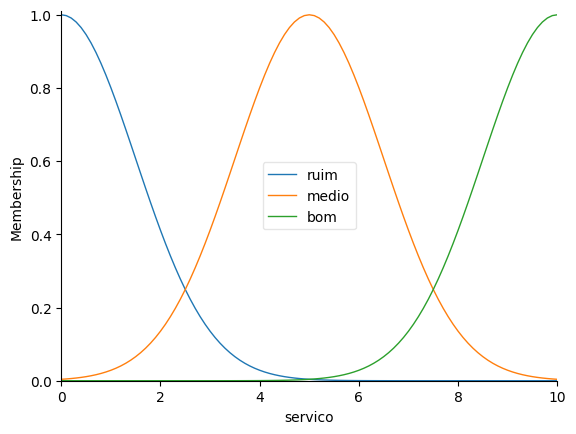

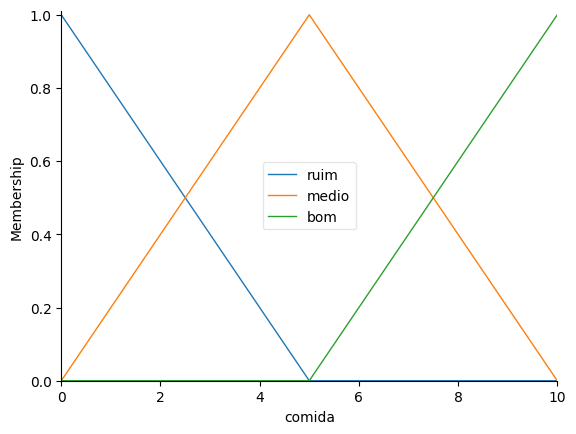

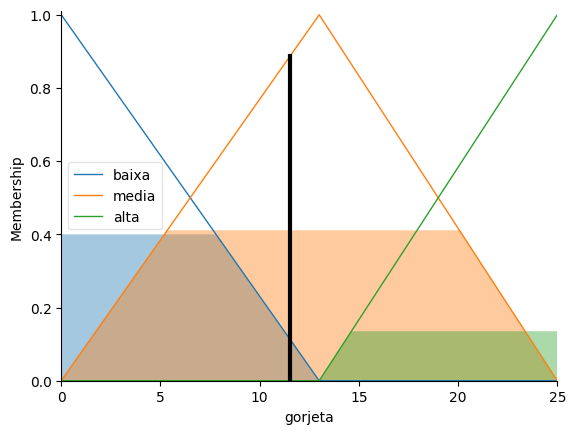

In [19]:
"""
AULA DE LÓGICA FUZZY - Código 2 (laboratório dos alunos)

Mesmo problema da gorjeta, agora com a biblioteca scikit-fuzzy.
Você vai: (1) rodar, (2) ver os gráficos, (3) fazer os experimentos no final.

Instalação:  pip install numpy matplotlib scikit-fuzzy
Execução:    python 02_laboratorio_skfuzzy.py
"""
import numpy as np
import matplotlib.pyplot as plt
import skfuzzy as fuzz
from skfuzzy import control as ctrl

# ---------- 1) Variáveis linguísticas (universos de discurso) ----------
servico = ctrl.Antecedent(np.arange(0, 10.01, 0.1), "servico")   # nota 0-10
comida = ctrl.Antecedent(np.arange(0, 10.01, 0.1), "comida")     # nota 0-10
gorjeta = ctrl.Consequent(np.arange(0, 25.01, 0.5), "gorjeta")   # % da conta

# ---------- 2) Conjuntos fuzzy (funções de pertinência) ----------
for var in (servico, comida):
    var["ruim"] = fuzz.trimf(var.universe, [0, 0, 5])
    var["medio"] = fuzz.trimf(var.universe, [0, 5, 10])
    var["bom"] = fuzz.trimf(var.universe, [5, 10, 10])

servico["ruim"] = fuzz.gaussmf(servico.universe, 0, 1.5)
servico["medio"] = fuzz.gaussmf(servico.universe, 5, 1.5)
servico["bom"] = fuzz.gaussmf(servico.universe, 10, 1.5)

comida["ruim"] = fuzz.trimf(comida.universe, [0, 0, 5])
comida["medio"] = fuzz.trimf(comida.universe, [0, 5, 10])
comida["bom"] = fuzz.trimf(comida.universe, [5, 10, 10])

gorjeta["baixa"] = fuzz.trimf(gorjeta.universe, [0, 0, 13])
gorjeta["media"] = fuzz.trimf(gorjeta.universe, [0, 13, 25])
gorjeta["alta"] = fuzz.trimf(gorjeta.universe, [13, 25, 25])

# ---------- 3) Base de regras  (| = OU, & = E, ~ = NÃO) ----------
regras = [
    ctrl.Rule(servico["ruim"] | comida["ruim"], gorjeta["baixa"]),
    ctrl.Rule(servico["medio"], gorjeta["media"]),
    ctrl.Rule(servico["bom"] | comida["bom"], gorjeta["alta"]),
]

# ---------- 4) Simulação ----------
sistema = ctrl.ControlSystem(regras)
sim = ctrl.ControlSystemSimulation(sistema)


def pedir_nota(texto, padrao):
    """Lê uma nota de 0 a 10; se o aluno só apertar Enter, usa o padrão."""
    resposta = input(f"{texto} (0-10) [{padrao}]: ").strip()
    return float(resposta.replace(",", ".")) if resposta else padrao


sim.input["servico"] = pedir_nota("Nota do serviço", 7)
sim.input["comida"] = pedir_nota("Nota da comida", 3)
sim.compute()
print(f"\n=> Gorjeta sugerida: {sim.output['gorjeta']:.1f}%")

# ---------- 5) Gráficos ----------
servico.view()                 # funções de pertinência do serviço
comida.view()                  # funções de pertinência da comida
gorjeta.view(sim=sim)          # área agregada + linha do centroide (resultado)
plt.show()

# ======================= EXPERIMENTOS =======================
# 1) Troque a regra 2 por:  servico["medio"] & comida["medio"]
#    O que mudou no resultado para (7, 3)? Por quê?
# 2) Troque os triângulos de "servico" por trapézios (fuzz.trapmf) ou
#    gaussianas (fuzz.gaussmf, [media, desvio]). O resultado ficou mais suave?
# 3) Compare métodos de defuzzificação:
#      gorjeta = ctrl.Consequent(np.arange(0, 25.01, 0.5), "gorjeta",
#                                defuzzify_method="mom")   # "centroid", "bisector", "mom"...
# 4) Adicione um 4º conjunto "excelente" ao serviço e escreva a regra nova.
# 5) Teste (0, 0), (10, 10), (5, 5): o comportamento é o que você esperava?


Nota do serviço (0-10) [7]: 
Nota da comida (0-10) [3]: 

=> Gorjeta sugerida: 12.8%


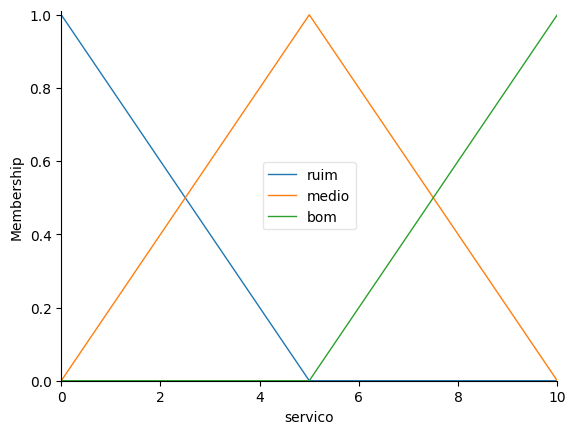

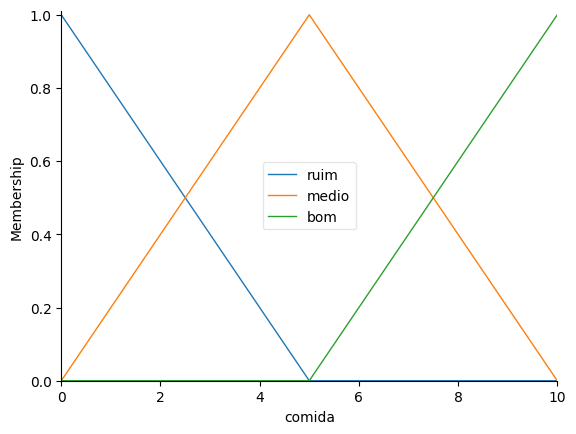

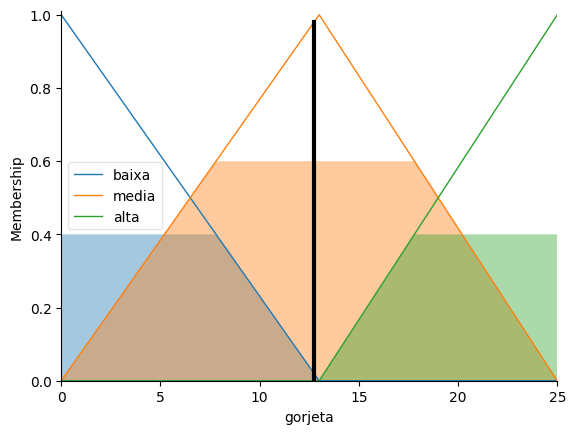

In [20]:
"""
AULA DE LÓGICA FUZZY - Código 2 (laboratório dos alunos)

Mesmo problema da gorjeta, agora com a biblioteca scikit-fuzzy.
Você vai: (1) rodar, (2) ver os gráficos, (3) fazer os experimentos no final.

Instalação:  pip install numpy matplotlib scikit-fuzzy
Execução:    python 02_laboratorio_skfuzzy.py
"""
import numpy as np
import matplotlib.pyplot as plt
import skfuzzy as fuzz
from skfuzzy import control as ctrl

# ---------- 1) Variáveis linguísticas (universos de discurso) ----------
servico = ctrl.Antecedent(np.arange(0, 10.01, 0.1), "servico")   # nota 0-10
comida = ctrl.Antecedent(np.arange(0, 10.01, 0.1), "comida")     # nota 0-10
gorjeta = ctrl.Consequent(np.arange(0, 25.01, 0.5), "gorjeta", defuzzify_method="mom")

# ---------- 2) Conjuntos fuzzy (funções de pertinência) ----------
for var in (servico, comida):
    var["ruim"] = fuzz.trimf(var.universe, [0, 0, 5])
    var["medio"] = fuzz.trimf(var.universe, [0, 5, 10])
    var["bom"] = fuzz.trimf(var.universe, [5, 10, 10])


gorjeta["baixa"] = fuzz.trimf(gorjeta.universe, [0, 0, 13])
gorjeta["media"] = fuzz.trimf(gorjeta.universe, [0, 13, 25])
gorjeta["alta"] = fuzz.trimf(gorjeta.universe, [13, 25, 25])

# ---------- 3) Base de regras  (| = OU, & = E, ~ = NÃO) ----------
regras = [
    ctrl.Rule(servico["ruim"] | comida["ruim"], gorjeta["baixa"]),
    ctrl.Rule(servico["medio"], gorjeta["media"]),
    ctrl.Rule(servico["bom"] | comida["bom"], gorjeta["alta"]),
]

# ---------- 4) Simulação ----------
sistema = ctrl.ControlSystem(regras)
sim = ctrl.ControlSystemSimulation(sistema)


def pedir_nota(texto, padrao):
    """Lê uma nota de 0 a 10; se o aluno só apertar Enter, usa o padrão."""
    resposta = input(f"{texto} (0-10) [{padrao}]: ").strip()
    return float(resposta.replace(",", ".")) if resposta else padrao


sim.input["servico"] = pedir_nota("Nota do serviço", 7)
sim.input["comida"] = pedir_nota("Nota da comida", 3)
sim.compute()
print(f"\n=> Gorjeta sugerida: {sim.output['gorjeta']:.1f}%")

# ---------- 5) Gráficos ----------
servico.view()                 # funções de pertinência do serviço
comida.view()                  # funções de pertinência da comida
gorjeta.view(sim=sim)          # área agregada + linha do centroide (resultado)
plt.show()

# ======================= EXPERIMENTOS =======================
# 1) Troque a regra 2 por:  servico["medio"] & comida["medio"]
#    O que mudou no resultado para (7, 3)? Por quê?
# 2) Troque os triângulos de "servico" por trapézios (fuzz.trapmf) ou
#    gaussianas (fuzz.gaussmf, [media, desvio]). O resultado ficou mais suave?
# 3) Compare métodos de defuzzificação:
#      gorjeta = ctrl.Consequent(np.arange(0, 25.01, 0.5), "gorjeta",
#                                defuzzify_method="mom")   # "centroid", "bisector", "mom"...
# 4) Adicione um 4º conjunto "excelente" ao serviço e escreva a regra nova.
# 5) Teste (0, 0), (10, 10), (5, 5): o comportamento é o que você esperava?


Nota do serviço (0-10) [7]: 10
Nota da comida (0-10) [3]: 10

=> Gorjeta sugerida: 21.0%


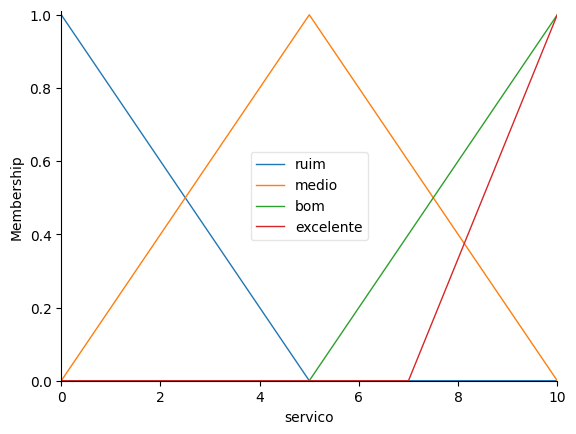

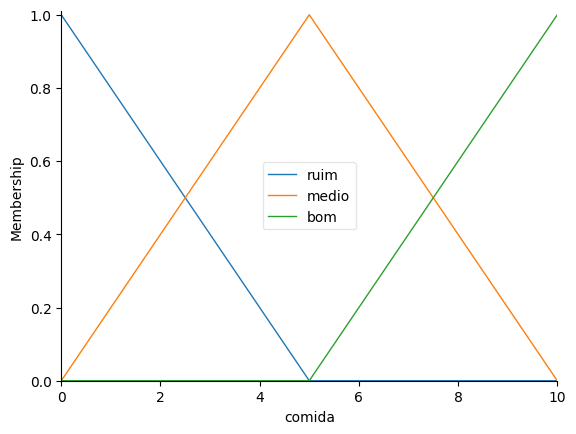

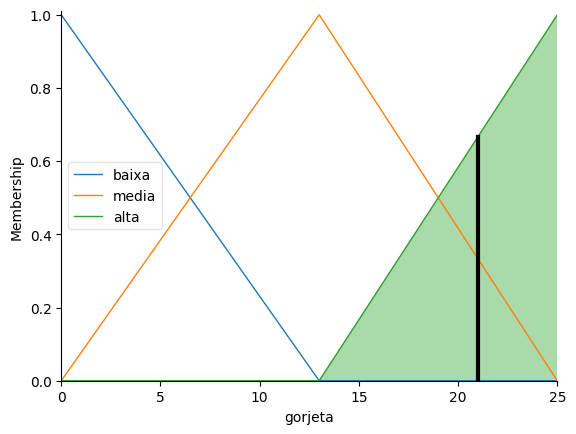

In [17]:
"""
AULA DE LÓGICA FUZZY - Código 2 (laboratório dos alunos)

Mesmo problema da gorjeta, agora com a biblioteca scikit-fuzzy.
Você vai: (1) rodar, (2) ver os gráficos, (3) fazer os experimentos no final.

Instalação:  pip install numpy matplotlib scikit-fuzzy
Execução:    python 02_laboratorio_skfuzzy.py
"""
import numpy as np
import matplotlib.pyplot as plt
import skfuzzy as fuzz
from skfuzzy import control as ctrl

# ---------- 1) Variáveis linguísticas (universos de discurso) ----------
servico = ctrl.Antecedent(np.arange(0, 10.01, 0.1), "servico")   # nota 0-10
comida = ctrl.Antecedent(np.arange(0, 10.01, 0.1), "comida")     # nota 0-10
gorjeta = ctrl.Consequent(np.arange(0, 25.01, 0.5), "gorjeta")   # % da conta

# ---------- 2) Conjuntos fuzzy (funções de pertinência) ----------
for var in (servico, comida):
    var["ruim"] = fuzz.trimf(var.universe, [0, 0, 5])
    var["medio"] = fuzz.trimf(var.universe, [0, 5, 10])
    var["bom"] = fuzz.trimf(var.universe, [5, 10, 10])

servico["excelente"] = fuzz.trimf(servico.universe, [7, 10, 10])

gorjeta["baixa"] = fuzz.trimf(gorjeta.universe, [0, 0, 13])
gorjeta["media"] = fuzz.trimf(gorjeta.universe, [0, 13, 25])
gorjeta["alta"] = fuzz.trimf(gorjeta.universe, [13, 25, 25])

# ---------- 3) Base de regras  (| = OU, & = E, ~ = NÃO) ----------
regras = [
    ctrl.Rule(servico["ruim"] | comida["ruim"], gorjeta["baixa"]),
    ctrl.Rule(servico["medio"], gorjeta["media"]),
    ctrl.Rule(servico["bom"] | comida["bom"], gorjeta["alta"]),
    ctrl.Rule(servico["excelente"] & comida["bom"], gorjeta["alta"]),
]

# ---------- 4) Simulação ----------
sistema = ctrl.ControlSystem(regras)
sim = ctrl.ControlSystemSimulation(sistema)


def pedir_nota(texto, padrao):
    """Lê uma nota de 0 a 10; se o aluno só apertar Enter, usa o padrão."""
    resposta = input(f"{texto} (0-10) [{padrao}]: ").strip()
    return float(resposta.replace(",", ".")) if resposta else padrao


sim.input["servico"] = pedir_nota("Nota do serviço", 7)
sim.input["comida"] = pedir_nota("Nota da comida", 3)
sim.compute()
print(f"\n=> Gorjeta sugerida: {sim.output['gorjeta']:.1f}%")

# ---------- 5) Gráficos ----------
servico.view()                 # funções de pertinência do serviço
comida.view()                  # funções de pertinência da comida
gorjeta.view(sim=sim)          # área agregada + linha do centroide (resultado)
plt.show()

# ======================= EXPERIMENTOS =======================
# 1) Troque a regra 2 por:  servico["medio"] & comida["medio"]
#    O que mudou no resultado para (7, 3)? Por quê?
# 2) Troque os triângulos de "servico" por trapézios (fuzz.trapmf) ou
#    gaussianas (fuzz.gaussmf, [media, desvio]). O resultado ficou mais suave?
# 3) Compare métodos de defuzzificação:
#      gorjeta = ctrl.Consequent(np.arange(0, 25.01, 0.5), "gorjeta",
#                                defuzzify_method="mom")   # "centroid", "bisector", "mom"...
# 4) Adicione um 4º conjunto "excelente" ao serviço e escreva a regra nova.
# 5) Teste (0, 0), (10, 10), (5, 5): o comportamento é o que você esperava?
